# Analysis: Known Issues in hypergraph.ipynb

## Critical

**The "hypergraph" is just cluster membership encoding, not a structural hypergraph**
`build_hyperedge_index` maps each cluster label → one hyperedge containing all member nodes.
With 7 clusters and 3,639 nodes this creates exactly 7 hyperedges of ~520 nodes each.
This is identical to the cluster assignment matrix — it encodes no spatial proximity,
gene co-expression, or any learned structure. The HGNN trained on this incidence matrix
cannot discover anything beyond what the upstream clustering already decided.
**Fix:** Build hyperedges from spatial k-NN neighborhoods, gene co-expression similarity,
or marker co-occurrence — sources independent of the labels the model is trying to learn.

**Hyperedges built from noisy, unstable cluster labels**
The upstream nested learning ARI fluctuates between 0.44 and 0.87 across iterations,
meaning the cluster labels used to define hyperedges are inconsistent and unreliable.
Training the HGNN on a hypergraph derived from noisy labels compounds all prior errors.

## Clustering

In [1]:
# Load preference: use nested hyperedges if present
from pathlib import Path
import numpy as np
import torch

nested_hyperedge_path = Path('Data/hyperedge_index_nested.npy')
nested_labels_path = Path('Data/spaformer_prepared/labels_nested.npy')
nested_latent_path = Path('Data/spaformer_prepared/latent_nested.npy')

PREFER_NESTED_CACHE = True
FORCE_REBUILD_HYPEREDGES = False

nested_available = nested_hyperedge_path.exists()
use_nested_hyperedges = bool(PREFER_NESTED_CACHE and nested_available and not FORCE_REBUILD_HYPEREDGES)
labels = None
embeddings_data = None

if FORCE_REBUILD_HYPEREDGES:
    print('FORCE_REBUILD_HYPEREDGES=True; ignoring cached nested hyperedges.')

if use_nested_hyperedges:
    hyperedge_index = np.load(nested_hyperedge_path)
    print(f'Using nested hyperedge index → {nested_hyperedge_path} ({hyperedge_index.shape})')
    if nested_latent_path.exists():
        embeddings_data = np.load(nested_latent_path)
        print(f'Loaded nested embeddings → {nested_latent_path} ({embeddings_data.shape})')
    if nested_labels_path.exists():
        labels = np.load(nested_labels_path)
        print(f'Loaded nested labels → {nested_labels_path} (unique={np.unique(labels).size})')
else:
    print('Using rebuild mode (or no nested cache); will run clustering to build hypergraph.')



Using nested hyperedge index → Data/hyperedge_index_nested.npy ((2, 3639))
Loaded nested embeddings → Data/spaformer_prepared/latent_nested.npy ((3639, 256))
Loaded nested labels → Data/spaformer_prepared/labels_nested.npy (unique=7)


In [2]:
if not use_nested_hyperedges:
    from sklearn.cluster import DBSCAN
    from sklearn import metrics
    import numpy as np
    import matplotlib.pyplot as plt

    from pathlib import Path
    embeddings_data = None
    feature_source = None
    feature_candidates = [
        Path('Data/spaformer_prepared/latent_refined.npy'),
        Path('Data/spaformer_prepared/latent.npy'),
    ]
    for cand in feature_candidates:
        if cand.exists():
            embeddings_data = np.load(cand)
            feature_source = cand
            break
    if embeddings_data is None:
        raise FileNotFoundError('No SpaFormer embeddings found (checked latent_refined.npy, latent.npy).')
    print(f'Using embeddings from {feature_source} (shape={embeddings_data.shape})')


In [3]:
if embeddings_data is not None:
    print(embeddings_data[2])


[-2.30157942e-01 -4.64139916e-02 -2.80041397e-01  1.35560608e+00
 -3.56512628e-02  7.94385523e-02  6.74360216e-01  1.02459323e+00
  1.98652005e+00  1.11195397e+00  1.72756463e-01  1.39107299e+00
  6.75965250e-01 -9.86587852e-02 -5.94917946e-02 -3.88652808e-03
 -3.24764661e-02 -1.80724159e-01  1.04220271e+00 -1.49147466e-01
 -1.43813774e-01  4.33798656e-02 -3.91649455e-02  3.85329545e-01
 -2.06231952e-01 -2.30392888e-01  7.66424537e-01  1.57428312e+00
  9.50633228e-01 -5.33609614e-02 -4.46153693e-02  2.21299842e-01
 -2.05164477e-02  1.49295521e+00 -1.10244364e-01  3.62112522e-01
  4.38754894e-02  8.75009239e-01 -5.25125340e-02 -3.07422310e-01
  8.25324237e-01 -2.08323672e-01 -2.26389244e-01 -3.24702233e-01
  2.54636824e-01 -2.30647773e-01 -2.27961153e-01 -1.69860438e-01
 -2.01858401e-01  3.72333378e-01 -2.81248719e-01 -1.73241459e-02
 -2.95906574e-01 -6.94331229e-02  4.74353522e-01 -5.98521568e-02
 -3.30671072e-02  5.44115782e-01 -1.12683721e-01 -1.41968265e-01
 -7.27802590e-02  3.82799

In [4]:
if not use_nested_hyperedges:
    clustering = DBSCAN(eps=0.8, min_samples=3).fit(embeddings_data)

    labels = clustering.labels_
    leiden_lbl_path = Path('Data/spaformer_prepared/leiden_labels.npy')
    if leiden_lbl_path.exists():
        labels = np.load(leiden_lbl_path)
        print(f'Using Leiden labels from {leiden_lbl_path}; unique clusters: {np.unique(labels).size}')
    else:
        print('Leiden label file not found; keeping DBSCAN labels.')

    try:
        import scanpy as sc
        adata_latent = sc.read_h5ad('Data/spaformer_prepared/latent.h5ad')
        if 'leiden' in adata_latent.obs:
            labels = adata_latent.obs['leiden'].astype('category').cat.codes.to_numpy()
            print('Using Leiden clusters from SpaFormer latent space for hyperedges.')
        else:
            print('Leiden labels not found in latent.h5ad; keep current labels.')
    except Exception as exc:
        print(f'Could not load latent.h5ad for Leiden labels: {exc}')

    if labels.shape[0] != embeddings_data.shape[0]:
        raise ValueError(f'label count {labels.shape[0]} != embeddings {embeddings_data.shape[0]}')

    def remap_labels(labels_in):
        labels_in = np.asarray(labels_in, dtype=int)
        valid_mask = labels_in != -1
        unique = np.unique(labels_in[valid_mask])
        mapping = {lab: i for i, lab in enumerate(unique)}
        remapped = np.full(labels_in.shape, -1, dtype=int)
        for lab, new in mapping.items():
            remapped[labels_in == lab] = new
        return remapped, int(len(unique))

    labels, n_clusters_ = remap_labels(labels)
    n_noise_ = int((labels == -1).sum())

    print("Estimated number of clusters: %d" % n_clusters_)
    print("Estimated number of noise points: %d" % n_noise_)

    if n_clusters_ > 1:
        try:
            valid = labels != -1
            score = metrics.silhouette_score(embeddings_data[valid], labels[valid])
            print(f"Silhouette Coefficient: {score:.3f}")
        except Exception as exc:
            print(f"Silhouette score unavailable: {exc}")


In [5]:
if not use_nested_hyperedges:
    clustering.n_features_in_
    clustering.labels_


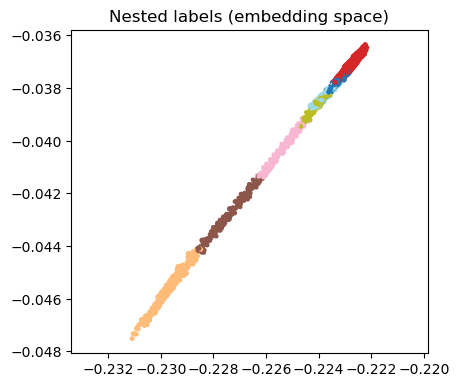

In [6]:
import matplotlib.pyplot as plt
if embeddings_data is not None and labels is not None:
    if use_nested_hyperedges:
        plt.figure(figsize=(4.6, 4.2))
        plt.scatter(embeddings_data[:, 0], embeddings_data[:, 1], c=labels, s=6, cmap='tab20')
        plt.title('Nested labels (embedding space)')
        plt.axis('equal')
        plt.show()
    else:
        plt.scatter(embeddings_data[:, 0], embeddings_data[:, 1])
        plt.show()

        core_samples_mask = np.zeros_like(labels, dtype=bool)
        core_samples_mask[clustering.core_sample_indices_] = True

        colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(labels))]
        for k, col in zip(labels, colors):
            if k == -1:
                # Black used for noise.
                col = [0, 0, 0, 1]

            class_member_mask = labels == k

            # Plot noise
            xy = embeddings_data[class_member_mask & ~core_samples_mask]
            plt.plot(
                xy[:, 0],
                xy[:, 1],
                "o",
                markerfacecolor=tuple(col),
                markeredgecolor="k",
                markersize=6,
            )

            # Plot cluster items
            xy = embeddings_data[class_member_mask & core_samples_mask]
            plt.plot(
                xy[:, 0],
                xy[:, 1],
                "o",
                markerfacecolor=tuple(col),
                markeredgecolor="k",
                markersize=6,
            )

        plt.title(f"Estimated number of clusters: {len(set(labels)) - (1 if -1 in labels else 0)}")
        plt.show()


if not use_nested_hyperedges:
    # [BUG] This function does NOT construct a true structural hypergraph.
    # It maps each cluster label to one hyperedge containing all member nodes.
    # The resulting incidence matrix is identical to the cluster assignment matrix —
    # it encodes no spatial proximity, gene co-expression, or any independently-learned
    # structure. With 7 clusters and 3639 nodes, only 7 hyperedges (~520 nodes each)
    # are created, making the HGNN's HypergraphConv equivalent to simple cluster-level
    # pooling. The HGNN then has no independent signal to learn from beyond what
    # upstream clustering already decided.
    # Fix: construct hyperedges from spatial k-NN neighborhoods, gene co-expression
    # similarity, or marker co-occurrence — independent of the cluster labels.
    def build_hyperedge_index(labels_in):
        labels_in = np.asarray(labels_in, dtype=int)
        valid_mask = labels_in != -1
        unique = np.unique(labels_in[valid_mask])
        mapping = {lab: i for i, lab in enumerate(unique)}
        remapped = np.full(labels_in.shape, -1, dtype=int)
        for lab, new in mapping.items():
            remapped[labels_in == lab] = new

        node_ids = []
        edge_ids = []
        for k in range(len(unique)):
            members = np.where(remapped == k)[0]
            if members.size == 0:
                continue
            node_ids.append(members.astype(np.int64))
            edge_ids.append(np.full(members.shape, k, dtype=np.int64))

        if node_ids:
            hyperedge_idx = np.vstack([
                np.concatenate(node_ids),
                np.concatenate(edge_ids),
            ])
        else:
            hyperedge_idx = np.zeros((2, 0), dtype=np.int64)
        return hyperedge_idx, remapped

    hyperedge_index, labels = build_hyperedge_index(labels)
    print('Hyperedge index shape:', hyperedge_index.shape)

In [7]:
if not use_nested_hyperedges:
    def build_hyperedge_index(labels_in):
        labels_in = np.asarray(labels_in, dtype=int)
        valid_mask = labels_in != -1
        unique = np.unique(labels_in[valid_mask])
        mapping = {lab: i for i, lab in enumerate(unique)}
        remapped = np.full(labels_in.shape, -1, dtype=int)
        for lab, new in mapping.items():
            remapped[labels_in == lab] = new

        node_ids = []
        edge_ids = []
        for k in range(len(unique)):
            members = np.where(remapped == k)[0]
            if members.size == 0:
                continue
            node_ids.append(members.astype(np.int64))
            edge_ids.append(np.full(members.shape, k, dtype=np.int64))

        if node_ids:
            hyperedge_idx = np.vstack([
                np.concatenate(node_ids),
                np.concatenate(edge_ids),
            ])
        else:
            hyperedge_idx = np.zeros((2, 0), dtype=np.int64)
        return hyperedge_idx, remapped

    hyperedge_index, labels = build_hyperedge_index(labels)
    print('Hyperedge index shape:', hyperedge_index.shape)


In [8]:
if not use_nested_hyperedges:
    hyperedge_index = torch.from_numpy(hyperedge_index)

print(hyperedge_index)


[[   4   12   17 ... 3487 3507 3512]
 [   0    0    0 ...    6    6    6]]


In [9]:
import numpy as np
if not use_nested_hyperedges:
    np.save("Data/hyperedge_index.npy", hyperedge_index.cpu().numpy() if hasattr(hyperedge_index, 'cpu') else hyperedge_index)
    print('Saved Data/hyperedge_index.npy')
else:
    print('Nested hyperedges already saved; skipping write.')


Nested hyperedges already saved; skipping write.


In [10]:
# from torch_geometric.nn import HypergraphConv

# test = HypergraphConv(len(embeddings_data), len(clustering.labels_))
# test(embeddings_data, hyperedge_index)

In [11]:
# from torch.utils.data import Dataset

# class EmbeddingDataset(Dataset):
# 	def __init__(self, data):
# 		self.data = data

# 	def __len__(self):
# 		return len(self.data)

# 	def __getitem__(self, index):
# 		return self.data[index]

In [12]:
# import torch.nn.functional as F
# from torch_geometric.nn import GCNConv

# class CNN(torch.nn.Module):
#     def __init__(self):
#         super().__init__()
#         self.conv1 = GCNConv(len(clustering.labels_), 16)

#     def forward(self, data):
#         x, edge_index = data.x, data.edge_index

#         x = self.conv1(x, edge_index)
#         x = F.relu(x)
#         x = F.dropout(x, training=self.training)
#         x = self.conv2(x, edge_index)

#         return F.log_softmax(x, dim=1)

In [13]:
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# model = GCN().to(device)
# data = dataset[0].to(device)
# optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

# model.train()
# for epoch in range(200):
#     optimizer.zero_grad()
#     out = model(data)
#     loss = F.nll_loss(out[data.train_mask], data.y[data.train_mask])
#     loss.backward()
#     optimizer.step()

## Grid Search (Ignore)

In [14]:
# highest_sil_coef = -1.0
# least_noise = 3000

# for i_eps in np.linspace(0, 1, 100, endpoint=False):
# 	if i_eps <= 0:
# 		continue

# 	for j_min_samples in range(1, 25):
# 		# print(i_eps, j_min_samples)
# 		try:
# 			cluster = DBSCAN(eps=i_eps, min_samples=j_min_samples).fit(data)
# 			labels = cluster.labels_
# 			sil_coef = metrics.silhouette_score(data, labels)
# 			cluster_count = len(set(labels)) - (1 if -1 in labels else 0)
# 			noise_count = list(labels).count(-1)

# 			# if highest_sil_coef < sil_coef and 3 < cluster_count < 100 and noise_count <= least_noise:
# 			# if highest_sil_coef < sil_coef and 3 < cluster_count and noise_count <= least_noise:
# 			if highest_sil_coef < sil_coef and 3 < cluster_count:
# 				highest_sil_coef = sil_coef
# 				least_noise = noise_count
# 				best_cluster = cluster

# 		except:
# 			continue

# print(highest_sil_coef)

In [15]:
# print(best_cluster)
# labels = best_cluster.labels_

# n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
# n_noise_ = list(labels).count(-1)

# print("Estimated number of clusters: %d" % n_clusters_)
# print("Estimated number of noise points: %d" % n_noise_)

# print(f"Silhouette Coefficient: {metrics.silhouette_score(data, labels):.3f}")

In [16]:
# plt.scatter(data[:, 0], data[:, 1])
# plt.show()

# unique_labels = set(labels)
# core_samples_mask = np.zeros_like(labels, dtype=bool)
# core_samples_mask[best_cluster.core_sample_indices_] = True

# colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]
# for k, col in zip(unique_labels, colors):
# 	if k == -1:
# 		# Black used for noise.
# 		col = [0, 0, 0, 1]

# 	class_member_mask = labels == k
    
# 	# Plot noise
# 	xy = data[class_member_mask & ~core_samples_mask]
# 	plt.plot(
# 		xy[:, 0],
# 		xy[:, 1],
# 		"o",
# 		markerfacecolor=tuple(col),
# 		markeredgecolor="k",
# 		markersize=6,
# 	)
    
# 	# Plot cluster items
# 	xy = data[class_member_mask & core_samples_mask]
# 	plt.plot(
# 		xy[:, 0],
# 		xy[:, 1],
# 		"o",
# 		markerfacecolor=tuple(col),
# 		markeredgecolor="k",
# 		markersize=6,
# 	)
    

# plt.title(f"Estimated number of clusters: {n_clusters_}")
# plt.show()